# 04 — Forecasting Baseline Model
**Day 3, Part 2.** Goal: train and evaluate a baseline next-day generation forecasting model on
`data/processed/daily_generation_features.csv`, and save the artifact for reuse by the dashboard
(Day 8) and copilot (Day 5).

Per the work plan: XGBoost/LightGBM as the primary baseline, chronological split (no shuffling),
evaluated with MAE, RMSE, MAPE.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import load_config, processed_path
from src.models.forecasting_model_utils import chronological_split, regression_metrics, save_model

cfg = load_config()


## 1. Load features and confirm the model library is available
Falls back to scikit-learn's HistGradientBoostingRegressor if XGBoost isn't installed, so this notebook never hard-blocks — but XGBoost is what the work plan specifies and what `requirements.txt` installs, so that's the primary path.

In [3]:
try:
    import xgboost as xgb
    MODEL_BACKEND = "xgboost"
    print("Using XGBoost")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    MODEL_BACKEND = "sklearn_fallback"
    print("XGBoost not found -- falling back to sklearn's HistGradientBoostingRegressor.")
    print("Run: pip install -r requirements.txt   to get XGBoost.")


Using XGBoost


In [4]:
daily = pd.read_csv(processed_path("daily_generation_features.csv", cfg), parse_dates=["timestamp"])
target_col = "target_next_1day_generation_kwh"
feature_cols = [c for c in daily.columns if c not in ["timestamp", "generation_kwh", target_col]]

print("Rows:", len(daily), " Features:", len(feature_cols))
daily.head()


Rows: 334  Features: 18


,timestamp,generation_kwh,mean_wind_speed,max_wind_speed,mean_wind_direction,mean_ambient_temp,mean_air_density,availability_pct,day_of_year,month,...,is_weekend,doy_sin,doy_cos,gen_lag_1d,gen_lag_2d,gen_lag_7d,gen_rolling_mean_7d,gen_rolling_mean_30d,wind_rolling_mean_7d,target_next_1day_generation_kwh
0,2025-01-31,19785.77,7.886806,13.40,226.771528,28.989097,1.168024,1.000000,31,1,...,0,0.508356,0.861147,23137.15,20557.43,18782.50,20854.892857,19267.213333,8.035536,22331.33
1,2025-02-01,22331.33,8.274097,12.91,226.802083,28.987917,1.167699,1.000000,32,2,...,1,0.523094,0.852275,19785.77,23137.15,22324.02,20998.217143,19372.859000,8.044266,19768.18
2,2025-02-02,19768.18,7.928889,13.83,224.671528,28.951181,1.167232,0.993056,33,2,...,1,0.537677,0.843151,22331.33,19785.77,21309.45,20999.261429,19527.449000,8.055744,20239.38
3,2025-02-03,20239.38,7.876667,13.98,224.841667,29.112153,1.166890,1.000000,34,2,...,0,0.552101,0.833777,19768.18,22331.33,20378.53,20779.080000,19565.646000,8.034008,21002.29
4,2025-02-04,21002.29,8.034444,13.09,223.554861,28.914097,1.168085,0.986111,35,2,...,0,0.566362,0.824157,20239.38,19768.18,19495.17,20759.201429,19664.011333,8.026944,22421.14


## 2. Chronological train/val/test split
70/15/15 by position, not randomly -- matches the ratios in `config/config.yaml`.

In [5]:
train, val, test = chronological_split(
    daily, train_frac=cfg["modeling"]["chronological_split"]["train"],
    val_frac=cfg["modeling"]["chronological_split"]["val"]
)
print(f"Train: {len(train)} ({train['timestamp'].min().date()} to {train['timestamp'].max().date()})")
print(f"Val:   {len(val)} ({val['timestamp'].min().date()} to {val['timestamp'].max().date()})")
print(f"Test:  {len(test)} ({test['timestamp'].min().date()} to {test['timestamp'].max().date()})")

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]


Train: 233 (2025-01-31 to 2025-09-20)
Val:   50 (2025-09-21 to 2025-11-09)
Test:  51 (2025-11-10 to 2025-12-30)


## 3. Train the baseline model

In [6]:
if MODEL_BACKEND == "xgboost":
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=cfg["modeling"]["random_seed"],
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
else:
    model = HistGradientBoostingRegressor(random_state=cfg["modeling"]["random_seed"])
    model.fit(X_train, y_train)

print("Model trained.")


Model trained.


## 4. Evaluate on the held-out test set

In [7]:
pred_test = model.predict(X_test)
metrics = regression_metrics(y_test, pred_test)
for name, value in metrics.items():
    print(f"{name}: {value:,.2f}" + ("%" if name == "MAPE" else " kWh"))


MAE: 1,363.43 kWh
RMSE: 1,658.12 kWh
MAPE: 8.99%


## 5. Visualization 1 — Actual vs. predicted generation over time
Required by the Day 4 work plan step; producing it now while the model is fresh.

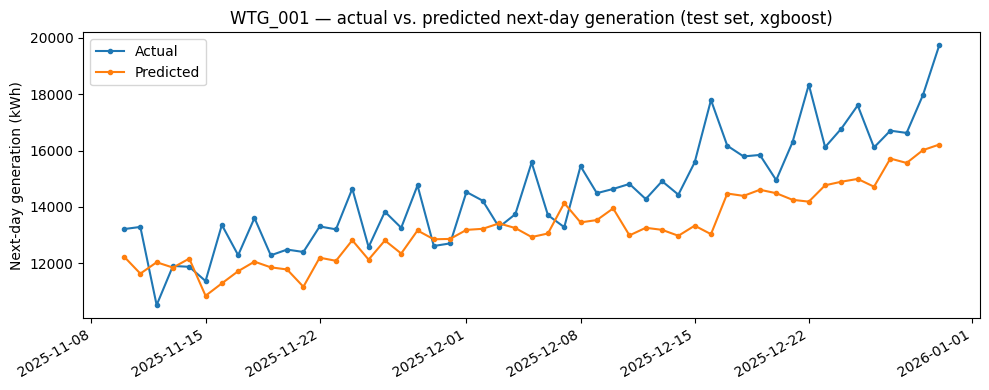

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test["timestamp"], y_test, label="Actual", marker="o", markersize=3)
ax.plot(test["timestamp"], pred_test, label="Predicted", marker="o", markersize=3)
ax.set_ylabel("Next-day generation (kWh)")
ax.set_title(f"WTG_001 — actual vs. predicted next-day generation (test set, {MODEL_BACKEND})")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day3_actual_vs_predicted.png", dpi=150)
plt.show()


## 6. Visualization 2 — Error distribution / residual plot

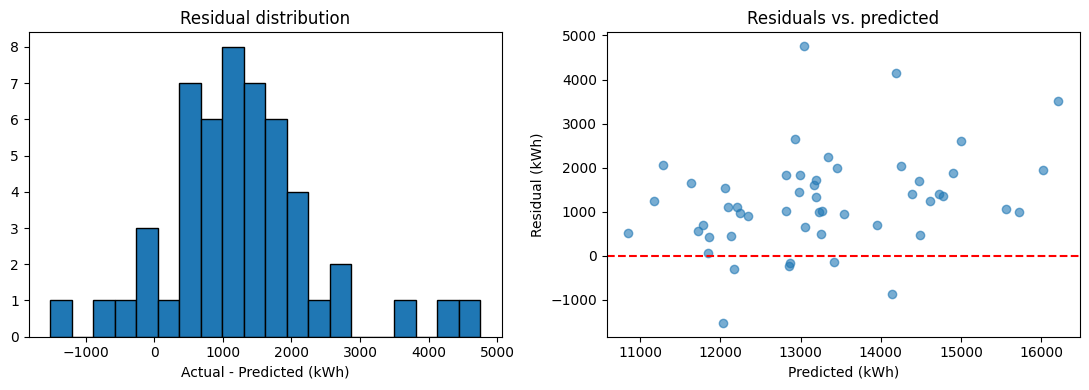

In [9]:
residuals = y_test.values - pred_test
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(residuals, bins=20, edgecolor="black")
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("Actual - Predicted (kWh)")

axes[1].scatter(pred_test, residuals, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted (kWh)")
axes[1].set_ylabel("Residual (kWh)")
axes[1].set_title("Residuals vs. predicted")

fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day3_residuals.png", dpi=150)
plt.show()


## 7. Visualization 3 — Feature importance

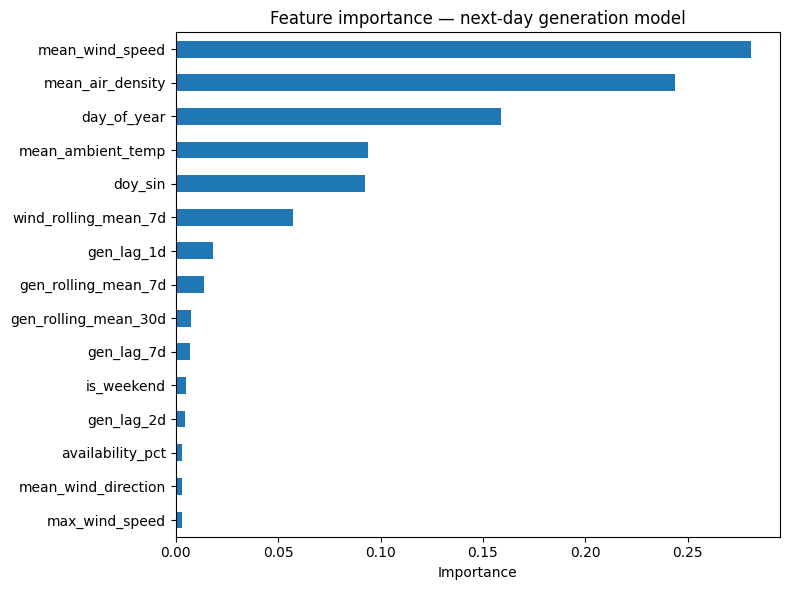

In [10]:
if MODEL_BACKEND == "xgboost":
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
else:
    importance = pd.Series(model.feature_importances_ if hasattr(model, "feature_importances_") else np.zeros(len(feature_cols)),
                            index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.tail(15).plot(kind="barh", ax=ax)
ax.set_title("Feature importance — next-day generation model")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day3_feature_importance.png", dpi=150)
plt.show()


## 8. Error analysis — where does the model perform worst?
The work plan's Day 4 step: identify low-performance conditions (e.g. low-wind days) and note likely causes.

In [11]:
test_analysis = test.copy()
test_analysis["predicted"] = pred_test
test_analysis["abs_error"] = np.abs(test_analysis[target_col] - test_analysis["predicted"])

worst = test_analysis.sort_values("abs_error", ascending=False).head(10)
worst[["timestamp", "mean_wind_speed", target_col, "predicted", "abs_error"]]


,timestamp,mean_wind_speed,target_next_1day_generation_kwh,predicted,abs_error
36,2025-12-16,7.268889,17792.43,13035.934570,4756.495430
42,2025-12-22,7.345694,18338.02,14188.678711,4149.341289
50,2025-12-30,7.489097,19733.66,16213.769531,3519.890469
25,2025-12-05,6.877569,15578.19,12933.923828,2644.266172
45,2025-12-25,7.403333,17603.39,14994.835938,2608.554062
35,2025-12-15,7.049792,15583.52,13336.826172,2246.693828
6,2025-11-16,6.456667,13363.25,11291.031250,2072.218750
41,2025-12-21,7.137500,16296.64,14254.655273,2041.984727
28,2025-12-08,6.731806,15446.79,13453.549805,1993.240195
49,2025-12-29,7.394931,17969.83,16016.319336,1953.510664


In [ ]:
# Does error correlate with wind conditions?
low_wind = test_analysis[test_analysis["mean_wind_speed"] < test_analysis["mean_wind_speed"].median()]
high_wind = test_analysis[test_analysis["mean_wind_speed"] >= test_analysis["mean_wind_speed"].median()]

print(f"Mean abs error, low-wind days:  {low_wind['abs_error'].mean():,.1f} kWh")
print(f"Mean abs error, high-wind days: {high_wind['abs_error'].mean():,.1f} kWh")


## 9. Save the model artifact
Saved with metadata (feature list + test metrics) so the dashboard and copilot can load it without needing to know how it was trained.

In [ ]:
model_path = PROJECT_ROOT / "models" / "next_day_generation_model.joblib"
save_model(
    model, model_path,
    metadata={
        "backend": MODEL_BACKEND,
        "feature_cols": feature_cols,
        "target_col": target_col,
        "test_metrics": metrics,
        "trained_on_rows": len(train),
        "turbine_id": "WTG_001",
    }
)
print("Saved:", model_path)


---
## Checkpoint — Day 3 complete

- `models/next_day_generation_model.joblib` exists with feature list + test metrics attached.
- Three required charts saved to `reports/figures/`: actual-vs-predicted, residuals, feature importance.
- Error analysis by wind level is in this notebook — carry the worst-case pattern (and the
  low-wind vs high-wind comparison above) into Day 4's one-page model summary.

**Known limitation to state plainly in the proposal:** this is a single-turbine (WTG_001),
wind-only, daily-resolution baseline — not a farm-wide or sub-daily production forecaster. That's
consistent with what the raw data actually supports (Day 1/2 findings), not a shortcut.

Next: Day 4 — demand forecasting proxy, hyperparameter tuning, and the one-page model summary for
the proposal appendix.